<a href="https://colab.research.google.com/github/mrfeagins01/Multi-Class-Prediction-of-Obesity-Risk/blob/main/DDS8555Assign8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Time series models
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

# Diagnostics
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Evaluation
from sklearn.metrics import mean_squared_error

In [42]:
#load datasets
train_sales = pd.read_csv("/content/train_sale.csv", parse_dates=["date"])
test_sales = pd.read_csv("/content/test_sale.csv", parse_dates=["date"])

print(train_sales.head())
print(train_sales.info())

   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB
None


In [43]:
#Creat daily sale series
# Aggregate total sales by date
daily_sales = train_sales.groupby("date")["sales"].sum()

# Set daily frequency
daily_sales = daily_sales.asfreq("D")

# Forward-fill missing dates if any exist
daily_sales = daily_sales.ffill()

print(daily_sales.head())
print(daily_sales.tail())

date
2013-01-01      2511.618999
2013-01-02    496092.417944
2013-01-03    361461.231124
2013-01-04    354459.677093
2013-01-05    477350.121229
Freq: D, Name: sales, dtype: float64
date
2017-08-11    826373.722022
2017-08-12    792630.535079
2017-08-13    865639.677471
2017-08-14    760922.406081
2017-08-15    762661.935939
Freq: D, Name: sales, dtype: float64


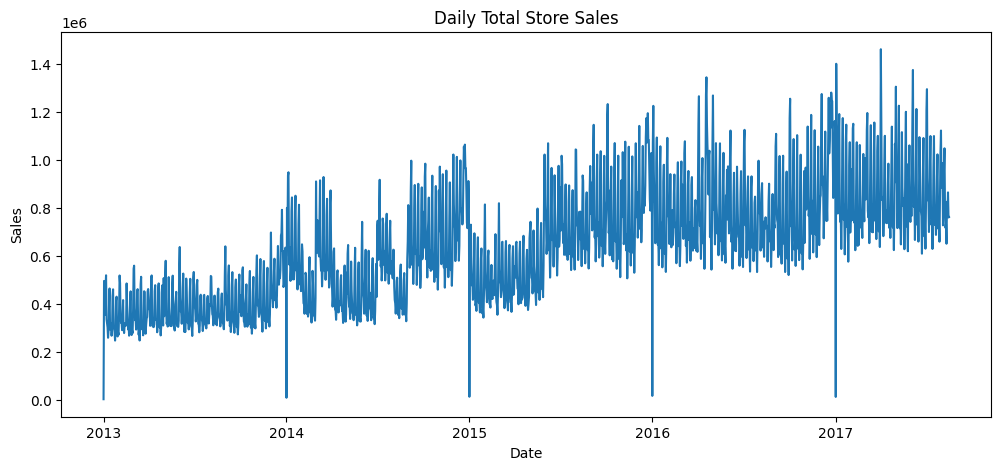

In [44]:
#visualize the series
plt.figure(figsize=(12, 5))
plt.plot(daily_sales)
plt.title("Daily Total Store Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [45]:
#Train/Validation Split
# Use the last 30 days as validation data
train_ts = daily_sales.iloc[:-30]
valid_ts = daily_sales.iloc[-30:]

print("Training period:", train_ts.index.min(), "to", train_ts.index.max())
print("Validation period:", valid_ts.index.min(), "to", valid_ts.index.max())

Training period: 2013-01-01 00:00:00 to 2017-07-16 00:00:00
Validation period: 2017-07-17 00:00:00 to 2017-08-15 00:00:00


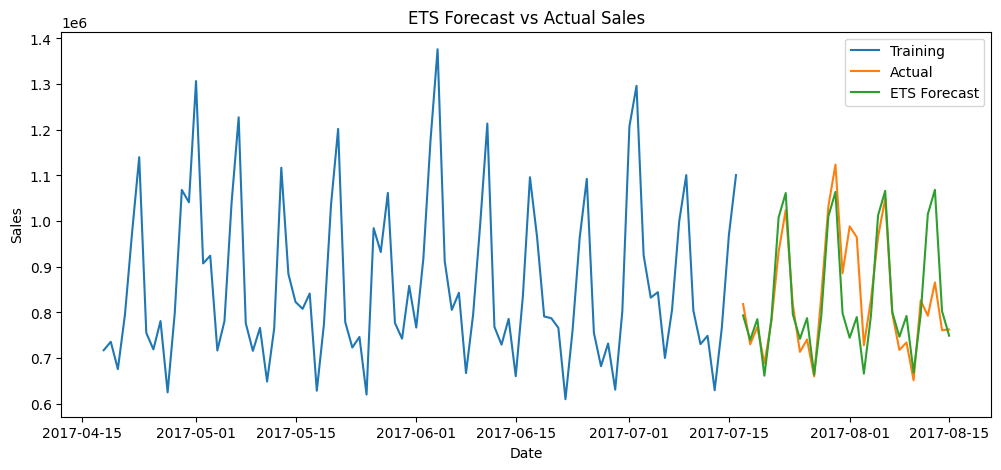

In [46]:
#ETS Model
ets_model = ExponentialSmoothing(
    train_ts,
    trend="add",
    seasonal="add",
    seasonal_periods=7
).fit()

ets_forecast = ets_model.forecast(30)

plt.figure(figsize=(12, 5))
plt.plot(train_ts.index[-90:], train_ts[-90:], label="Training")
plt.plot(valid_ts.index, valid_ts, label="Actual")
plt.plot(valid_ts.index, ets_forecast, label="ETS Forecast")
plt.title("ETS Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

In [47]:
#model evaluation
ets_mse = mean_squared_error(valid_ts, ets_forecast)
ets_rmse = np.sqrt(ets_mse)
print("ETS RMSE:", ets_rmse)


ETS RMSE: 85954.50574908465


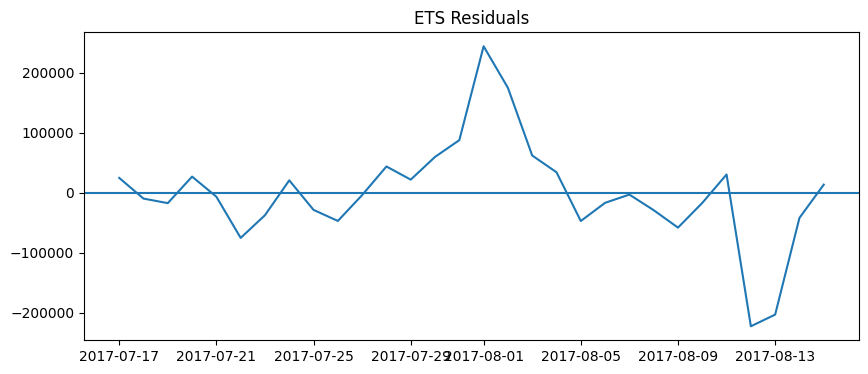

    lb_stat  lb_pvalue
10  24.4015   0.006603


In [48]:
# ETS residuals
ets_residuals = valid_ts - ets_forecast

plt.figure(figsize=(10, 4))
plt.plot(ets_residuals)
plt.axhline(0)
plt.title("ETS Residuals")
plt.show()

print(acorr_ljungbox(ets_residuals, lags=[10], return_df=True))

In [49]:
# ARIMA model
arima_model = ARIMA(train_ts, order=(2, 1, 2)).fit()

arima_forecast = arima_model.forecast(30)

# Evaluation
ets_mse = mean_squared_error(valid_ts, ets_forecast)
arima_mse = mean_squared_error(valid_ts, arima_forecast)

ets_rmse = np.sqrt(ets_mse)
arima_rmse = np.sqrt(arima_mse)

print("ETS RMSE:", ets_rmse)
print("ARIMA RMSE:", arima_rmse)

# Residual diagnostics
ets_resid = valid_ts - ets_forecast
arima_resid = valid_ts - arima_forecast

print("\nARIMA Ljung-Box Test")
print(acorr_ljungbox(arima_resid, lags=[10], return_df=True))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ETS RMSE: 85954.50574908465
ARIMA RMSE: 128839.24203342569

ARIMA Ljung-Box Test
      lb_stat  lb_pvalue
10  23.240962   0.009891


In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import preprocessing

from sklearn.linear_model import ElasticNet, Lasso,  BayesianRidge, LassoLarsIC
from sklearn.ensemble import RandomForestRegressor,  GradientBoostingRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

import lightgbm as lgb
import warnings


In [51]:
house_train = pd.read_csv('/content/train_house.csv')
house_test = pd.read_csv('/content/test_house.csv')

In [52]:
# Separate target variable
y = np.log1p(house_train["SalePrice"])

# Drop ID and target
X = house_train.drop(["Id", "SalePrice"], axis=1)
X_test = house_test.drop(["Id"], axis=1)

# Combine train and test for consistent preprocessing
combined = pd.concat([X, X_test], axis=0)

# Fill missing values
for col in combined.columns:
    if combined[col].dtype == "object":
        combined[col] = combined[col].fillna("Missing")
    else:
        combined[col] = combined[col].fillna(combined[col].median())

# Create dichotomous variables
combined_encoded = pd.get_dummies(combined, drop_first=True)

# Split back into train and test
X_encoded = combined_encoded.iloc[:len(X), :]
X_test_encoded = combined_encoded.iloc[len(X):, :]

print(X_encoded.shape)

(1460, 267)


In [53]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42
)

In [54]:
#Multiple regression
model1 = LinearRegression()

model1.fit(X_train, y_train)

pred1 = model1.predict(X_valid)

rmse1 = np.sqrt(mean_squared_error(y_valid, pred1))

print("Model 1 Linear Regression RMSE:", rmse1)

Model 1 Linear Regression RMSE: 0.1736665657367537


In [55]:
#Ridge regression
model2 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=50)),
    ("ridge", Ridge(alpha=10))
])

model2.fit(X_train, y_train)

pred2 = model2.predict(X_valid)

rmse2 = np.sqrt(mean_squared_error(y_valid, pred2))

print("Model 2 Ridge + PCA RMSE:", rmse2)

Model 2 Ridge + PCA RMSE: 0.15639056764083356


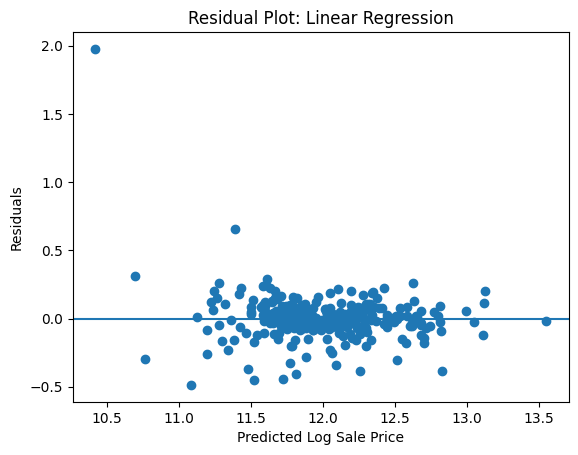

In [20]:
#asssumption check
# Residuals for Model 1
residuals1 = y_valid - pred1

plt.scatter(pred1, residuals1)
plt.axhline(y=0)
plt.xlabel("Predicted Log Sale Price")
plt.ylabel("Residuals")
plt.title("Residual Plot: Linear Regression")
plt.show()

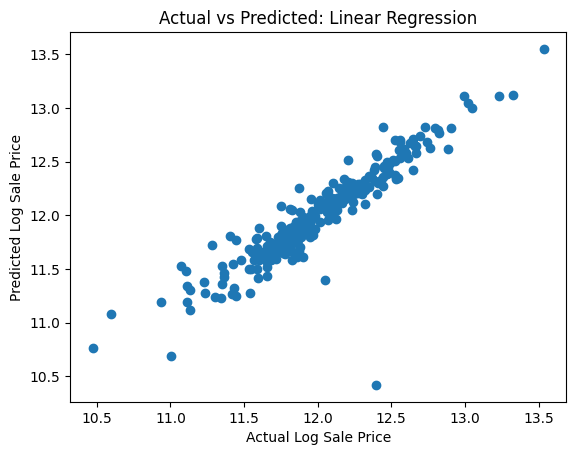

In [21]:
#asssumption check
# Predicted vs Actual
plt.scatter(y_valid, pred1)
plt.xlabel("Actual Log Sale Price")
plt.ylabel("Predicted Log Sale Price")
plt.title("Actual vs Predicted: Linear Regression")
plt.show()

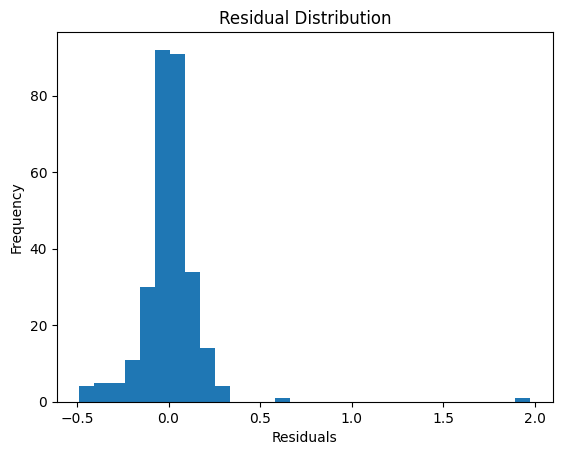

In [22]:
#asssumption check
# Residual distribution
plt.hist(residuals1, bins=30)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

In [26]:
# San Francisco Crime Classification - imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.pipeline import Pipeline

In [29]:
# Load San Francisco Crime data

crime_train = pd.read_csv("/train_crime.csv", parse_dates=["Dates"])
crime_test = pd.read_csv("/test_crime.csv", parse_dates=["Dates"])

print(crime_train.head())
print(crime_train.info())
print(crime_train["Category"].value_counts().head())

                Dates        Category                      Descript  \
0 2015-05-13 23:53:00        WARRANTS                WARRANT ARREST   
1 2015-05-13 23:53:00  OTHER OFFENSES      TRAFFIC VIOLATION ARREST   
2 2015-05-13 23:33:00  OTHER OFFENSES      TRAFFIC VIOLATION ARREST   
3 2015-05-13 23:30:00   LARCENY/THEFT  GRAND THEFT FROM LOCKED AUTO   
4 2015-05-13 23:30:00   LARCENY/THEFT  GRAND THEFT FROM LOCKED AUTO   

   DayOfWeek PdDistrict      Resolution                    Address  \
0  Wednesday   NORTHERN  ARREST, BOOKED         OAK ST / LAGUNA ST   
1  Wednesday   NORTHERN  ARREST, BOOKED         OAK ST / LAGUNA ST   
2  Wednesday   NORTHERN  ARREST, BOOKED  VANNESS AV / GREENWICH ST   
3  Wednesday   NORTHERN            NONE   1500 Block of LOMBARD ST   
4  Wednesday       PARK            NONE  100 Block of BRODERICK ST   

            X          Y  
0 -122.425892  37.774599  
1 -122.425892  37.774599  
2 -122.424363  37.800414  
3 -122.426995  37.800873  
4 -122.438738  37

In [30]:
# Feature engineering function

def prepare_crime_features(df):
    df = df.copy()

    df["Year"] = df["Dates"].dt.year
    df["Month"] = df["Dates"].dt.month
    df["Day"] = df["Dates"].dt.day
    df["Hour"] = df["Dates"].dt.hour
    df["DayOfWeek_num"] = df["Dates"].dt.dayofweek

    # Drop high-cardinality or nonpredictive text fields for simple modeling
    drop_cols = ["Dates", "Descript", "Resolution", "Address"]
    for col in drop_cols:
        if col in df.columns:
            df = df.drop(columns=col)

    return df

In [31]:
crime_train_prepared = prepare_crime_features(crime_train)
crime_test_prepared = prepare_crime_features(crime_test)

# Separate target
y = crime_train_prepared["Category"]
X = crime_train_prepared.drop(columns=["Category"])

# Drop Id from test features but keep it for submission
test_ids = crime_test_prepared["Id"]
X_test = crime_test_prepared.drop(columns=["Id"])

# Encode target
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# One-hot encode categorical predictors
X_encoded = pd.get_dummies(X, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

# Align columns between train and test
X_encoded, X_test_encoded = X_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

print(X_encoded.shape)
print(X_test_encoded.shape)

(878049, 22)
(884262, 22)


In [32]:
# Train-validation split

X_train, X_valid, y_train, y_valid = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

In [33]:
# Model 1: Decision Tree

tree_model = DecisionTreeClassifier(
    max_depth=15,
    min_samples_leaf=25,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_valid)
tree_proba = tree_model.predict_proba(X_valid)

tree_acc = accuracy_score(y_valid, tree_pred)
tree_logloss = log_loss(y_valid, tree_proba)

print("Decision Tree Accuracy:", tree_acc)
print("Decision Tree Log Loss:", tree_logloss)

Decision Tree Accuracy: 0.27108365127270656
Decision Tree Log Loss: 4.001091485449828


In [34]:
# Model 2: Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_valid)
rf_proba = rf_model.predict_proba(X_valid)

rf_acc = accuracy_score(y_valid, rf_pred)
rf_logloss = log_loss(y_valid, rf_proba)

print("Random Forest Accuracy:", rf_acc)
print("Random Forest Log Loss:", rf_logloss)

Random Forest Accuracy: 0.28029724958715335
Random Forest Log Loss: 2.409105118571367


In [35]:
# Model 3: Support Vector Machine

svm_model = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("svm", LinearSVC(random_state=42, max_iter=5000))
])

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_valid)

svm_acc = accuracy_score(y_valid, svm_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.22369455042423553


In [36]:
# Classification reports

print("Decision Tree Classification Report")
print(classification_report(y_valid, tree_pred, target_names=label_encoder.classes_))

print("Random Forest Classification Report")
print(classification_report(y_valid, rf_pred, target_names=label_encoder.classes_))

print("SVM Classification Report")
print(classification_report(y_valid, svm_pred, target_names=label_encoder.classes_))

Decision Tree Classification Report
                             precision    recall  f1-score   support

                      ARSON       0.00      0.00      0.00       303
                    ASSAULT       0.18      0.14      0.16     15375
                 BAD CHECKS       0.00      0.00      0.00        81
                    BRIBERY       0.00      0.00      0.00        58
                   BURGLARY       0.14      0.04      0.06      7351
         DISORDERLY CONDUCT       0.17      0.03      0.06       864
DRIVING UNDER THE INFLUENCE       0.00      0.00      0.00       454
              DRUG/NARCOTIC       0.32      0.41      0.36     10794
                DRUNKENNESS       0.06      0.00      0.00       856
               EMBEZZLEMENT       0.08      0.00      0.01       233
                  EXTORTION       0.00      0.00      0.00        51
            FAMILY OFFENSES       0.00      0.00      0.00        98
     FORGERY/COUNTERFEITING       0.18      0.03      0.06      21

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

                             precision    recall  f1-score   support

                      ARSON       0.00      0.00      0.00       303
                    ASSAULT       0.22      0.06      0.10     15375
                 BAD CHECKS       0.00      0.00      0.00        81
                    BRIBERY       0.00      0.00      0.00        58
                   BURGLARY       0.34      0.00      0.00      7351
         DISORDERLY CONDUCT       0.00      0.00      0.00       864
DRIVING UNDER THE INFLUENCE       0.00      0.00      0.00       454
              DRUG/NARCOTIC       0.33      0.43      0.37     10794
                DRUNKENNESS       0.00      0.00      0.00       856
               EMBEZZLEMENT       0.00      0.00      0.00       233
                  EXTORTION       0.00      0.00      0.00        51
            FAMILY OFFENSES       0.00      0.00      0.00        98
     FORGERY/COUNTERFEITING       0.00      0.00      0.00      2122
                      FRAUD      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [37]:
# Compare model performance

model_results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "SVM"],
    "Accuracy": [tree_acc, rf_acc, svm_acc],
    "Log Loss": [tree_logloss, rf_logloss, np.nan]
})

print(model_results)

           Model  Accuracy  Log Loss
0  Decision Tree  0.271084  4.001091
1  Random Forest  0.280297  2.409105
2            SVM  0.223695       NaN


                  Feature  Importance
1                       Y    0.247248
0                       X    0.230230
5                    Hour    0.121550
2                    Year    0.098188
4                     Day    0.081118
3                   Month    0.067374
21  PdDistrict_TENDERLOIN    0.034764
6           DayOfWeek_num    0.027308
19    PdDistrict_SOUTHERN    0.014830
13     PdDistrict_CENTRAL    0.008763
16    PdDistrict_NORTHERN    0.007983
15     PdDistrict_MISSION    0.007521
14   PdDistrict_INGLESIDE    0.006826
10     DayOfWeek_Thursday    0.006661
12    DayOfWeek_Wednesday    0.006461


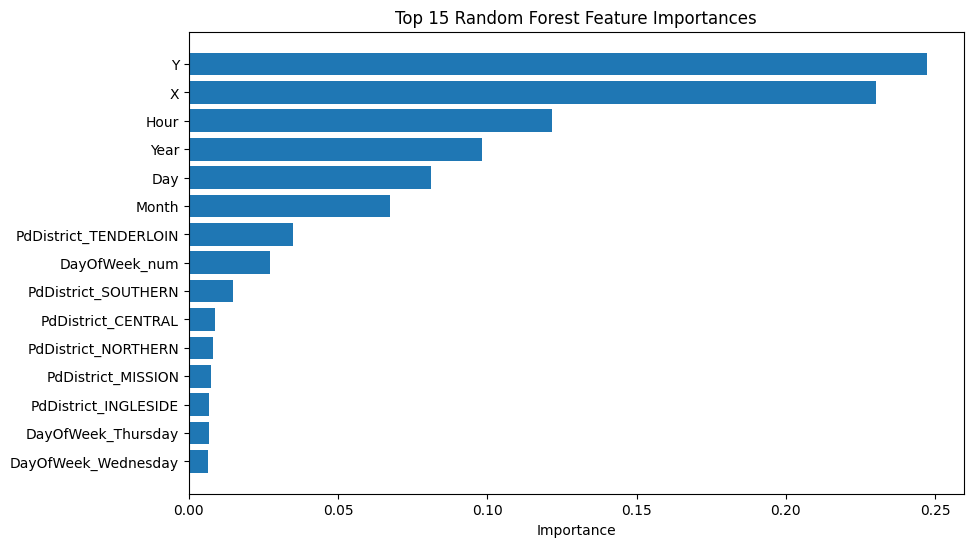

In [38]:
# Feature importance for Random Forest

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(15))

plt.figure(figsize=(10, 6))
plt.barh(
    feature_importance.head(15)["Feature"],
    feature_importance.head(15)["Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 15 Random Forest Feature Importances")
plt.show()

In [39]:
# Choose final model based on validation results
# Usually Random Forest is preferred here if it has the lowest log loss.

final_model = rf_model

# Fit final model on all training data
final_model.fit(X_encoded, y_encoded)

# Predict probabilities for Kaggle test data
final_proba = final_model.predict_proba(X_test_encoded)

# Create Kaggle submission
submission = pd.DataFrame(
    final_proba,
    columns=label_encoder.classes_
)

submission.insert(0, "Id", test_ids)

submission.to_csv("sf_crime_submission.csv", index=False)

print(submission.head())
print(submission.shape)

   Id     ARSON   ASSAULT    BAD CHECKS   BRIBERY  BURGLARY  \
0   0  0.004126  0.102004  1.298643e-05  0.000218  0.025254   
1   1  0.003730  0.114970  1.307346e-05  0.000739  0.017740   
2   2  0.004408  0.072193  7.380074e-05  0.000003  0.071632   
3   3  0.000968  0.068330  6.450364e-07  0.000010  0.007207   
4   4  0.000968  0.068330  6.450364e-07  0.000010  0.007207   

   DISORDERLY CONDUCT  DRIVING UNDER THE INFLUENCE  DRUG/NARCOTIC  \
0            0.002847                     0.006026       0.042163   
1            0.001804                     0.005090       0.056303   
2            0.001554                     0.000982       0.017907   
3            0.000660                     0.007006       0.035691   
4            0.000660                     0.007006       0.035691   

   DRUNKENNESS  ...  SEX OFFENSES NON FORCIBLE  STOLEN PROPERTY   SUICIDE  \
0     0.002045  ...                   0.000403         0.003414  0.000589   
1     0.006454  ...                   0.000281      

In [57]:
# ============================================================
# SAN FRANCISCO CRIME SUBMISSION FIX
# ============================================================

# Recreate crime features using separate variable names

crime_train_prepared = prepare_crime_features(crime_train)
crime_test_prepared = prepare_crime_features(crime_test)

# Separate target
crime_y = crime_train_prepared["Category"]
crime_X = crime_train_prepared.drop(columns=["Category"])

# Save test Ids
crime_test_ids = crime_test_prepared["Id"]
crime_X_test = crime_test_prepared.drop(columns=["Id"])

# Encode target
crime_label_encoder = LabelEncoder()
crime_y_encoded = crime_label_encoder.fit_transform(crime_y)

# One-hot encode predictors
crime_X_encoded = pd.get_dummies(crime_X, drop_first=True)
crime_X_test_encoded = pd.get_dummies(crime_X_test, drop_first=True)

# Align train and test columns
crime_X_encoded, crime_X_test_encoded = crime_X_encoded.align(
    crime_X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

print(crime_X_encoded.shape)
print(crime_X_test_encoded.shape)
print(len(crime_y_encoded))

(878049, 22)
(884262, 22)
878049


In [64]:
# Refit Random Forest on all San Francisco Crime training data
final_crime_model = rf_model

final_crime_model.fit(crime_X_encoded, crime_y_encoded)

# Predict probabilities for test data
crime_probabilities = final_crime_model.predict_proba(crime_X_test_encoded)

# Reduce file size and memory usage

crime_submission_optimized = crime_submission.copy()

# Convert probabilities to float32
for col in crime_submission_optimized.columns[1:]:
    crime_submission_optimized[col] = crime_submission_optimized[col].astype("float32")

# Round probabilities
crime_submission_optimized.iloc[:, 1:] = (
    crime_submission_optimized.iloc[:, 1:].round(6)
)

# Save efficiently
crime_submission_optimized.to_csv(
    "sf_crime_submission.csv",
    index=False,
    float_format="%.6f"
)

print("Optimized SF Crime submission created.")
print(crime_submission_optimized.shape)

KeyboardInterrupt: 

In [61]:
#create all three submission files

import pandas as pd
import numpy as np

# ============================================================
# 1. STORE SALES SUBMISSION
# Required columns: id, sales
# Uses the better time series model: ETS
# ============================================================

# Forecast for each unique test date
store_future_dates = sorted(test_sales["date"].unique())

store_forecast = ets_model.forecast(len(store_future_dates))

store_forecast_df = pd.DataFrame({
    "date": store_future_dates,
    "sales": store_forecast.values
})

# Merge daily forecast back to each test row
store_submission = test_sales[["id", "date"]].merge(
    store_forecast_df,
    on="date",
    how="left"
)

store_submission = store_submission[["id", "sales"]]

# Sales cannot be negative
store_submission["sales"] = store_submission["sales"].clip(lower=0)

store_submission.to_csv("store_sales_submission.csv", index=False)

print("Store Sales submission created:")
print(store_submission.head())
print(store_submission.shape)


# ============================================================
# 2. HOUSE PRICES SUBMISSION
# Required columns: Id, SalePrice
# Uses the better model: Ridge + PCA
# ============================================================

# Refit Ridge + PCA model on all training data
final_house_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=50)),
    ("ridge", Ridge(alpha=10))
])

final_house_model.fit(X_encoded, y)

# Predict test data
house_predictions_log = final_house_model.predict(X_test_encoded)

# Convert back from log scale
house_predictions = np.expm1(house_predictions_log)

house_submission = pd.DataFrame({
    "Id": house_test["Id"],
    "SalePrice": house_predictions
})

house_submission.to_csv("house_prices_submission.csv", index=False)

print("\nHouse Prices submission created:")
print(house_submission.head())
print(house_submission.shape)


# ============================================================
# VERIFY FILES WERE CREATED
# ============================================================

import os

print("\nSubmission files in notebook directory:")
for file in os.listdir():
    if file.endswith(".csv"):
        print(file)

Store Sales submission created:
        id          sales
0  3000888  793516.828968
1  3000889  793516.828968
2  3000890  793516.828968
3  3000891  793516.828968
4  3000892  793516.828968
(28512, 2)

House Prices submission created:
     Id      SalePrice
0  1461  112069.250086
1  1462  162030.423080
2  1463  176761.842744
3  1464  205938.241485
4  1465  181492.055578
(1459, 2)

Submission files in notebook directory:
house_prices_submission.csv
test_crime.csv
store_sales_submission.csv
test_house.csv
train_crime.csv
test_sale.csv
train_house.csv
train_sale.csv


In [68]:
print(X_train.shape)
print(crime_X_test_encoded.shape)

(1168, 267)
(884262, 22)


In [69]:
# Create SF Crime train-validation split

from sklearn.model_selection import train_test_split

crime_X_train, crime_X_valid, crime_y_train, crime_y_valid = train_test_split(
    crime_X_encoded,
    crime_y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=crime_y_encoded
)

print(crime_X_train.shape)
print(crime_X_test_encoded.shape)

(702439, 22)
(884262, 22)


In [70]:
from sklearn.ensemble import RandomForestClassifier

fast_rf_model = RandomForestClassifier(
    n_estimators=25,
    max_depth=15,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)

fast_rf_model.fit(crime_X_train, crime_y_train)

crime_probabilities = fast_rf_model.predict_proba(crime_X_test_encoded)

crime_submission = pd.DataFrame(
    crime_probabilities.astype("float32"),
    columns=crime_label_encoder.classes_
)

crime_submission.insert(0, "Id", crime_test_ids.values)

crime_submission.to_csv(
    "sf_crime_submission.csv",
    index=False,
    float_format="%.6f"
)

print("San Francisco Crime submission created:")
print(crime_submission.head())
print(crime_submission.shape)

San Francisco Crime submission created:
   Id     ARSON   ASSAULT  BAD CHECKS   BRIBERY  BURGLARY  DISORDERLY CONDUCT  \
0   0  0.002648  0.106672    0.000033  0.000411  0.028550            0.000991   
1   1  0.004421  0.141453    0.000142  0.000934  0.025932            0.001876   
2   2  0.006013  0.065363    0.000966  0.000009  0.074030            0.001185   
3   3  0.003269  0.068865    0.000000  0.000903  0.012296            0.004248   
4   4  0.003269  0.068865    0.000000  0.000903  0.012296            0.004248   

   DRIVING UNDER THE INFLUENCE  DRUG/NARCOTIC  DRUNKENNESS  ...  \
0                     0.002611       0.036660     0.002705  ...   
1                     0.002798       0.048551     0.003947  ...   
2                     0.003989       0.022529     0.004376  ...   
3                     0.009249       0.026952     0.003403  ...   
4                     0.009249       0.026952     0.003403  ...   

   SEX OFFENSES NON FORCIBLE  STOLEN PROPERTY   SUICIDE  SUSPICIOUS OC

In [71]:
import os

for file in os.listdir():
    if "sf_crime" in file:
        print(file, os.path.getsize(file))

In [72]:
crime_submission.to_csv(
    "sf_crime_submission.csv",
    index=False,
    float_format="%.6f"
)

In [75]:
import zipfile
import os

# Make sure CSV is saved in working directory
crime_submission.to_csv(
    "/content/sf_crime_submission.csv",
    index=False,
    float_format="%.6f"
)

# Zip the CSV
zip_path = "/content/sf_crime_submission.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    zipf.write(
        "/content/sf_crime_submission.csv",
        arcname="sf_crime_submission.csv"
    )

print("ZIP created:", zip_path)
print("ZIP size:", os.path.getsize(zip_path) / (1024 * 1024), "MB")

ZIP created: /content/sf_crime_submission.zip
ZIP size: 75.37040996551514 MB


In [76]:
!kaggle competitions submit -c sf-crime -f /kaggle/working/sf_crime_submission.csv -m "Random Forest submission"

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [77]:
import os

print(os.path.exists("/kaggle/working/sf_crime_submission.csv"))
print(os.path.exists("/kaggle/working/sf_crime_submission.zip"))

False
False


In [78]:
# Save SF Crime submission safely in chunks

output_path = "/kaggle/working/sf_crime_submission.csv"

chunk_size = 100000

# Write header first
crime_submission.iloc[:0].to_csv(
    output_path,
    index=False
)

# Append chunks
for start in range(0, len(crime_submission), chunk_size):

    end = start + chunk_size

    crime_submission.iloc[start:end].to_csv(
        output_path,
        mode="a",
        header=False,
        index=False,
        float_format="%.6f"
    )

    print(f"Wrote rows {start} to {end}")

print("Finished saving:", output_path)

OSError: Cannot save file into a non-existent directory: '/kaggle/working'

In [79]:
import os

print(os.getcwd())

/content


In [80]:
output_path = "/content/sf_crime_submission.csv"

chunk_size = 100000

crime_submission.iloc[:0].to_csv(output_path, index=False)

for start in range(0, len(crime_submission), chunk_size):
    end = start + chunk_size

    crime_submission.iloc[start:end].to_csv(
        output_path,
        mode="a",
        header=False,
        index=False,
        float_format="%.6f"
    )

    print(f"Wrote rows {start} to {min(end, len(crime_submission))}")

print("Finished saving:", output_path)

Wrote rows 0 to 100000
Wrote rows 100000 to 200000
Wrote rows 200000 to 300000
Wrote rows 300000 to 400000
Wrote rows 400000 to 500000
Wrote rows 500000 to 600000
Wrote rows 600000 to 700000
Wrote rows 700000 to 800000
Wrote rows 800000 to 884262
Finished saving: /content/sf_crime_submission.csv


In [81]:
import os

print(os.path.exists("/content/sf_crime_submission.csv"))
print(os.path.getsize("/content/sf_crime_submission.csv") / (1024*1024), "MB")

True
267.75912857055664 MB


In [82]:
from google.colab import files

files.download("/content/sf_crime_submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [83]:
# Fix SF Crime submission file for Kaggle

output_path = "/content/sf_crime_submission_fixed.csv"

# Make sure Id is a column, not index
crime_submission = crime_submission.reset_index(drop=True)

# Confirm first columns
print(crime_submission.columns[:5])

# Save clean file
crime_submission.to_csv(
    output_path,
    index=False,
    float_format="%.6f"
)

print("Saved:", output_path)
print(crime_submission.head())

Index(['Id', 'ARSON', 'ASSAULT', 'BAD CHECKS', 'BRIBERY'], dtype='object')
Saved: /content/sf_crime_submission_fixed.csv
   Id     ARSON   ASSAULT  BAD CHECKS   BRIBERY  BURGLARY  DISORDERLY CONDUCT  \
0   0  0.002648  0.106672    0.000033  0.000411  0.028550            0.000991   
1   1  0.004421  0.141453    0.000142  0.000934  0.025932            0.001876   
2   2  0.006013  0.065363    0.000966  0.000009  0.074030            0.001185   
3   3  0.003269  0.068865    0.000000  0.000903  0.012296            0.004248   
4   4  0.003269  0.068865    0.000000  0.000903  0.012296            0.004248   

   DRIVING UNDER THE INFLUENCE  DRUG/NARCOTIC  DRUNKENNESS  ...  \
0                     0.002611       0.036660     0.002705  ...   
1                     0.002798       0.048551     0.003947  ...   
2                     0.003989       0.022529     0.004376  ...   
3                     0.009249       0.026952     0.003403  ...   
4                     0.009249       0.026952     0.00340

In [84]:
pd.read_csv("/content/sf_crime_submission_fixed.csv", nrows=5).head()

,Id,ARSON,ASSAULT,BAD CHECKS,BRIBERY,BURGLARY,DISORDERLY CONDUCT,DRIVING UNDER THE INFLUENCE,DRUG/NARCOTIC,DRUNKENNESS,...,SEX OFFENSES NON FORCIBLE,STOLEN PROPERTY,SUICIDE,SUSPICIOUS OCC,TREA,TRESPASS,VANDALISM,VEHICLE THEFT,WARRANTS,WEAPON LAWS
0,0,0.002648,0.106672,0.000033,0.000411,0.028550,0.000991,0.002611,0.036660,0.002705,...,0.000049,0.005950,0.000177,0.043210,0.000021,0.004271,0.067185,0.102133,0.044367,0.022080
1,1,0.004421,0.141453,0.000142,0.000934,0.025932,0.001876,0.002798,0.048551,0.003947,...,0.000190,0.006039,0.000107,0.050495,0.000021,0.002826,0.066397,0.067870,0.055433,0.027282
2,2,0.006013,0.065363,0.000966,0.000009,0.074030,0.001185,0.003989,0.022529,0.004376,...,0.000000,0.005791,0.000099,0.028092,0.000000,0.006502,0.065861,0.066772,0.020852,0.004905
3,3,0.003269,0.068865,0.000000,0.000903,0.012296,0.004248,0.009249,0.026952,0.003403,...,0.000029,0.003920,0.000000,0.043011,0.000000,0.003584,0.071081,0.174404,0.027692,0.014391
4,4,0.003269,0.068865,0.000000,0.000903,0.012296,0.004248,0.009249,0.026952,0.003403,...,0.000029,0.003920,0.000000,0.043011,0.000000,0.003584,0.071081,0.174404,0.027692,0.014391


In [85]:
from google.colab import files
files.download("/content/sf_crime_submission_fixed.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>